In [71]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor, RandomForestRegressor, StackingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.inspection import permutation_importance

In [2]:
data = pd.read_csv('housing.csv')

In [3]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [6]:
data.dropna(inplace=True)

In [7]:
data.info()

<class 'pandas.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.9 MB


In [8]:
from sklearn.model_selection import train_test_split 

X = data.drop(['median_house_value'], axis=1)
y=data['median_house_value']

In [10]:
X_train, X_text, y_train, y_text = train_test_split(X, y, test_size=0.2)

In [11]:
train_data = X_train.join(y_train)

In [12]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
8376,-118.34,33.95,25.0,3762.0,1281.0,4015.0,1178.0,2.1587,<1H OCEAN,143800.0
17960,-121.99,37.33,33.0,2023.0,425.0,1016.0,405.0,3.9417,<1H OCEAN,285800.0
7996,-118.15,33.86,32.0,2630.0,559.0,1069.0,491.0,2.4659,<1H OCEAN,209000.0
2053,-119.73,36.68,32.0,755.0,205.0,681.0,207.0,1.7986,INLAND,49300.0
6431,-118.01,34.13,38.0,3374.0,671.0,1906.0,640.0,4.0729,INLAND,212300.0
...,...,...,...,...,...,...,...,...,...,...
15,-122.26,37.85,50.0,1120.0,283.0,697.0,264.0,2.1250,NEAR BAY,140000.0
5831,-118.32,34.20,36.0,2110.0,346.0,984.0,342.0,6.9909,<1H OCEAN,345300.0
20043,-119.00,36.07,20.0,1042.0,183.0,509.0,175.0,2.9815,INLAND,73000.0
2569,-124.14,40.78,35.0,2426.0,423.0,982.0,432.0,3.4219,NEAR OCEAN,92800.0


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

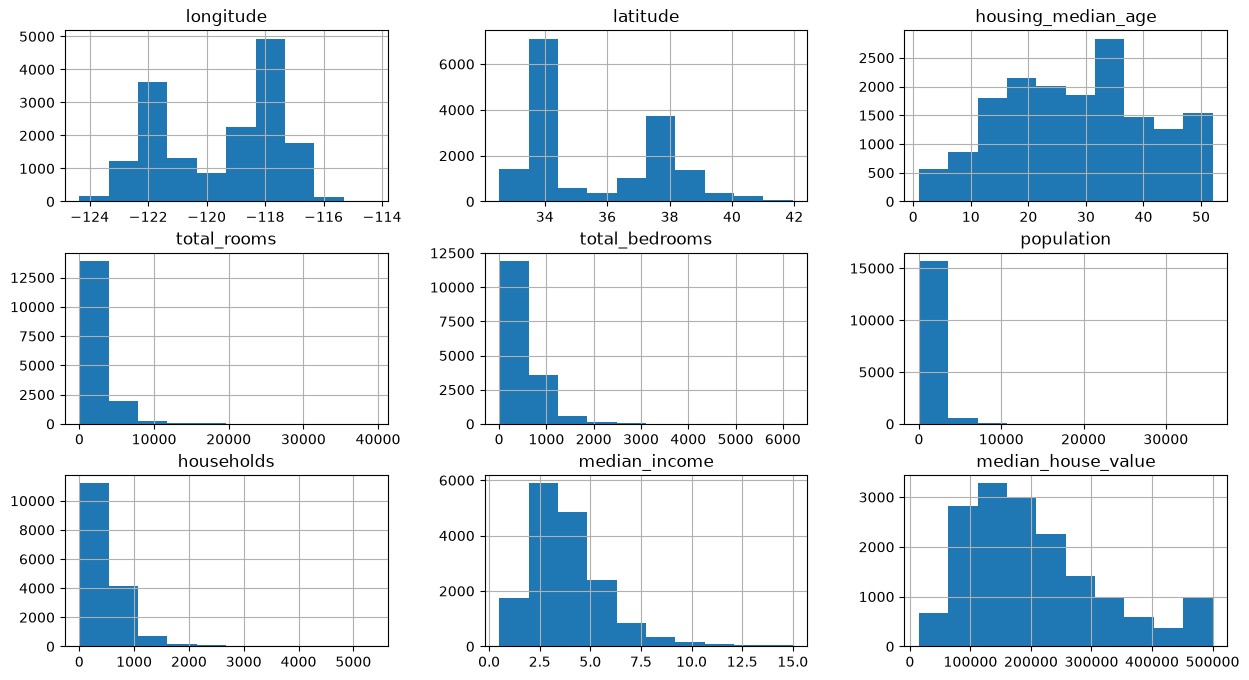

In [14]:
train_data.hist(figsize=(15,8))

In [18]:
train_data.corr(numeric_only=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.925581,-0.110572,0.043153,0.067976,0.099333,0.055001,-0.018832,-0.048522
latitude,-0.925581,1.000000,0.013395,-0.034651,-0.066437,-0.109386,-0.071696,-0.075440,-0.139549
housing_median_age,-0.110572,0.013395,1.000000,-0.357971,-0.319426,-0.293594,-0.301430,-0.118357,0.107617
total_rooms,0.043153,-0.034651,-0.357971,1.000000,0.928425,0.855822,0.916601,0.197528,0.134671
total_bedrooms,0.067976,-0.066437,-0.319426,0.928425,1.000000,0.875485,0.978700,-0.008508,0.052458
population,0.099333,-0.109386,-0.293594,0.855822,0.875485,1.000000,0.906098,0.006362,-0.023321
households,0.055001,-0.071696,-0.301430,0.916601,0.978700,0.906098,1.000000,0.013415,0.067377
median_income,-0.018832,-0.075440,-0.118357,0.197528,-0.008508,0.006362,0.013415,1.000000,0.684937
median_house_value,-0.048522,-0.139549,0.107617,0.134671,0.052458,-0.023321,0.067377,0.684937,1.000000


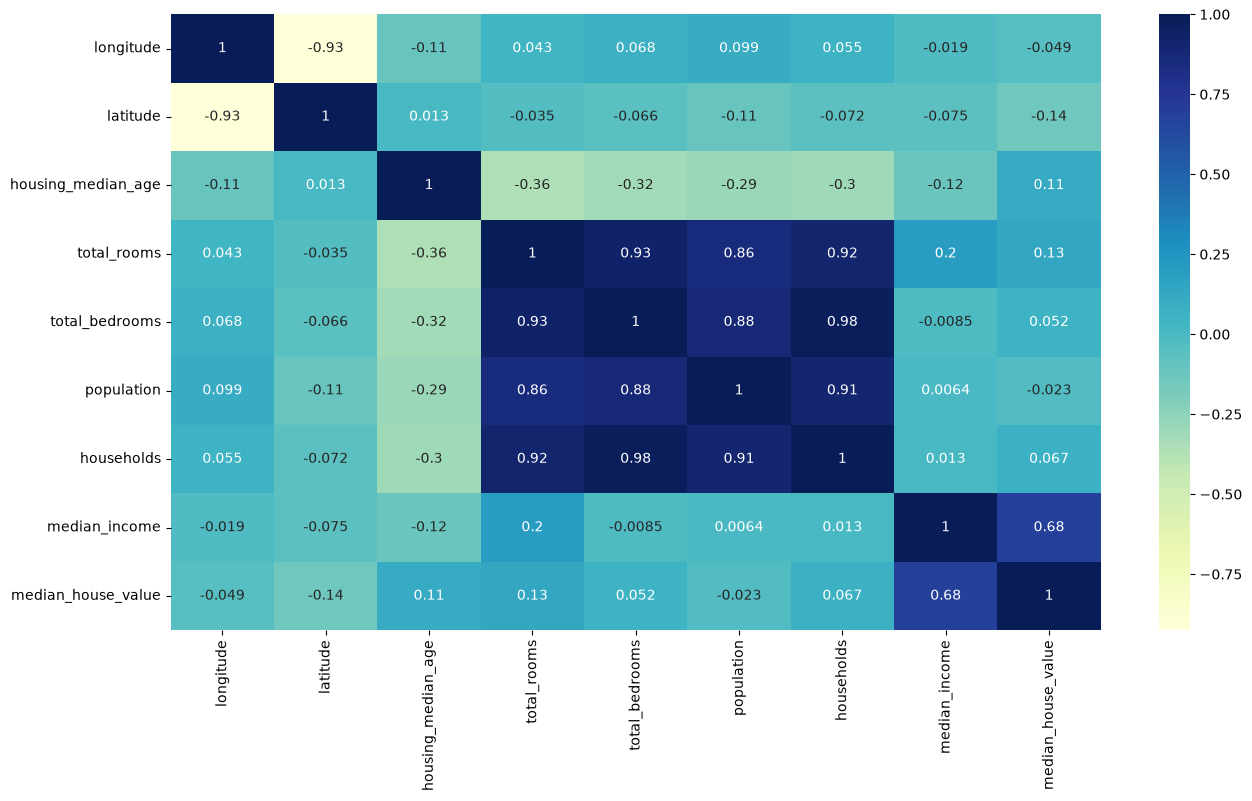

In [20]:
plt.figure(figsize=(15,8))

sns.heatmap(
    train_data.corr(numeric_only=True),
    annot=True,
    cmap='YlGnBu'
)

plt.show()

In [21]:
train_data['total_rooms'] = np.log(train_data['total_rooms']+1)
train_data['total_bedrooms'] = np.log(train_data['total_bedrooms']+1)
train_data['population'] = np.log(train_data['population']+1)
train_data['households'] = np.log(train_data['households']+1)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

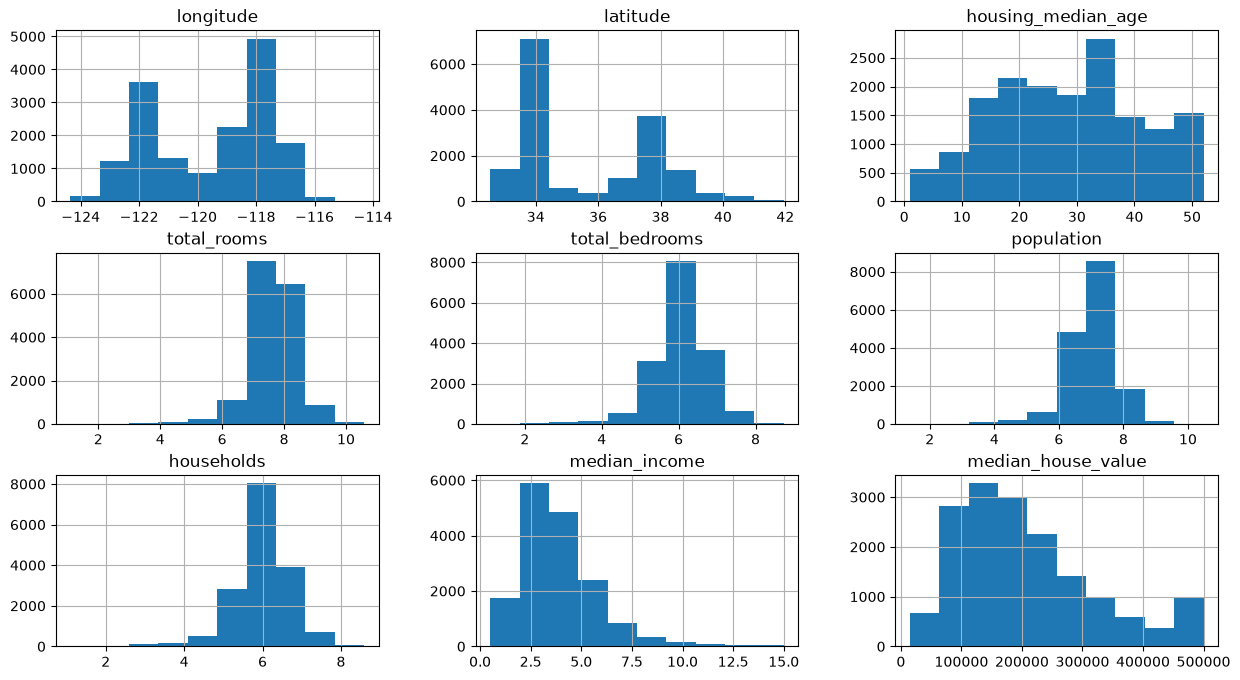

In [22]:
train_data.hist(figsize=(15,8))

In [44]:
train_data.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
longitude,16346.0,-119.573109,2.006625,-124.350000,-121.800000,-118.490000,-118.000000,-114.310000
latitude,16346.0,35.633162,2.133847,32.540000,33.930000,34.260000,37.710000,41.950000
housing_median_age,16346.0,28.559097,12.554496,1.000000,18.000000,29.000000,37.000000,52.000000
total_rooms,16346.0,7.630903,0.745692,1.098612,7.282761,7.667158,8.051341,10.579514
total_bedrooms,16346.0,6.055246,0.722462,1.098612,5.693732,6.075346,6.472346,8.734077
population,16346.0,7.025793,0.732397,1.386294,6.668228,7.062192,7.451096,10.482430
households,16346.0,5.985666,0.721478,1.098612,5.638355,6.016157,6.403574,8.586533
median_income,16346.0,3.877093,1.887445,0.499900,2.572900,3.546150,4.755450,15.000100
median_house_value,16346.0,206885.381500,114732.371789,14999.000000,120800.000000,180500.000000,264500.000000,500001.000000


In [29]:
train_data.ocean_proximity.value_counts()

ocean_proximity
<1H OCEAN     7258
INLAND        5176
NEAR OCEAN    2109
NEAR BAY      1799
ISLAND           4
Name: count, dtype: int64

In [31]:
train_data = train_data.drop('ocean_proximity', axis=1)

In [32]:
bool_cols = train_data.select_dtypes(include='bool').columns
train_data[bool_cols] = train_data[bool_cols].astype(int)

In [33]:
train_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
8376,-118.34,33.95,25.0,8.232972,7.156177,8.298042,7.072422,2.1587,143800.0
17960,-121.99,37.33,33.0,7.612831,6.054439,6.924612,6.006353,3.9417,285800.0
7996,-118.15,33.86,32.0,7.875119,6.327937,6.975414,6.198479,2.4659,209000.0
2053,-119.73,36.68,32.0,6.628041,5.327876,6.525030,5.337538,1.7986,49300.0
6431,-118.01,34.13,38.0,8.124151,6.510258,7.553287,6.463029,4.0729,212300.0


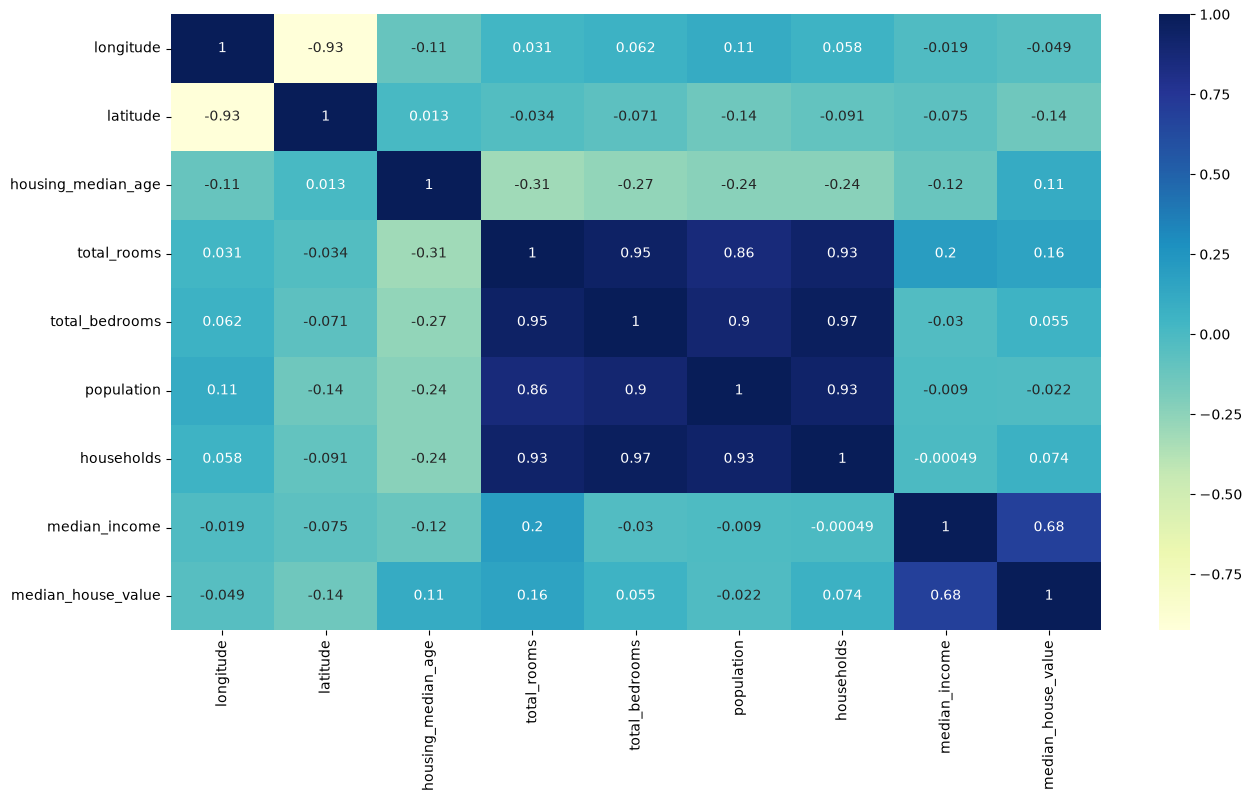

In [34]:
plt.figure(figsize=(15,8))

sns.heatmap(
    train_data.corr(numeric_only=True),
    annot=True,
    cmap='YlGnBu'
)

plt.show()

In [37]:
print(train_data.columns.tolist())

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']


In [47]:
missing = train_data.isnull().sum().sort_values(ascending=False)

missing_train_data = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": (missing / len(train_data) * 100).round(2)
})

missing_train_data[missing_train_data["Missing Values"] > 0]

,Missing Values,Percentage


In [48]:
print("Number of duplicate rows:", train_data.duplicated().sum())

Number of duplicate rows: 0


In [49]:
train_data = train_data.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", train_data.shape)

Shape after removing duplicates: (16346, 9)


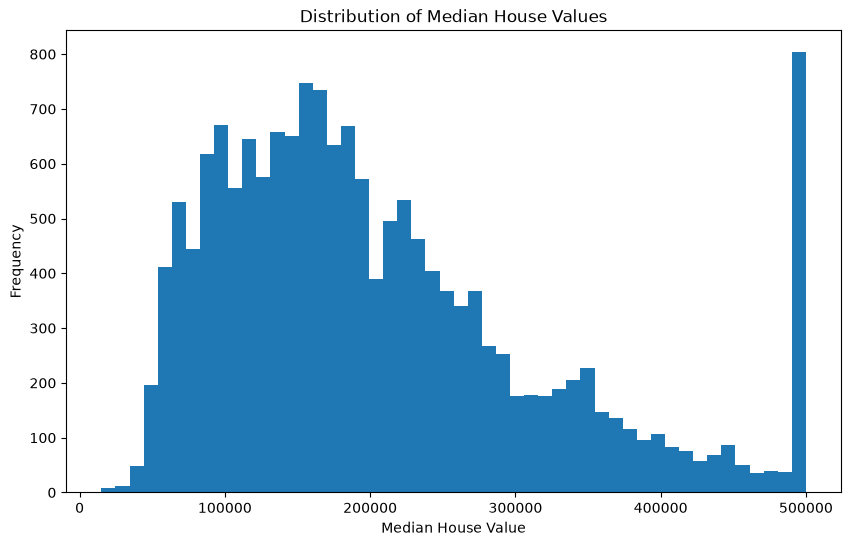

In [51]:

plt.figure(figsize=(10, 6))

plt.hist(train_data["median_house_value"], bins=50)

plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.title("Distribution of Median House Values")

plt.show()

In [52]:
numeric_train_data = train_data.select_dtypes(include=np.number)

correlation = numeric_train_data.corr()["median_house_value"].sort_values(ascending=False)

print(correlation)

median_house_value    1.000000
median_income         0.684937
total_rooms           0.159220
housing_median_age    0.107617
households            0.074069
total_bedrooms        0.055147
population           -0.021922
longitude            -0.048522
latitude             -0.139549
Name: median_house_value, dtype: float64


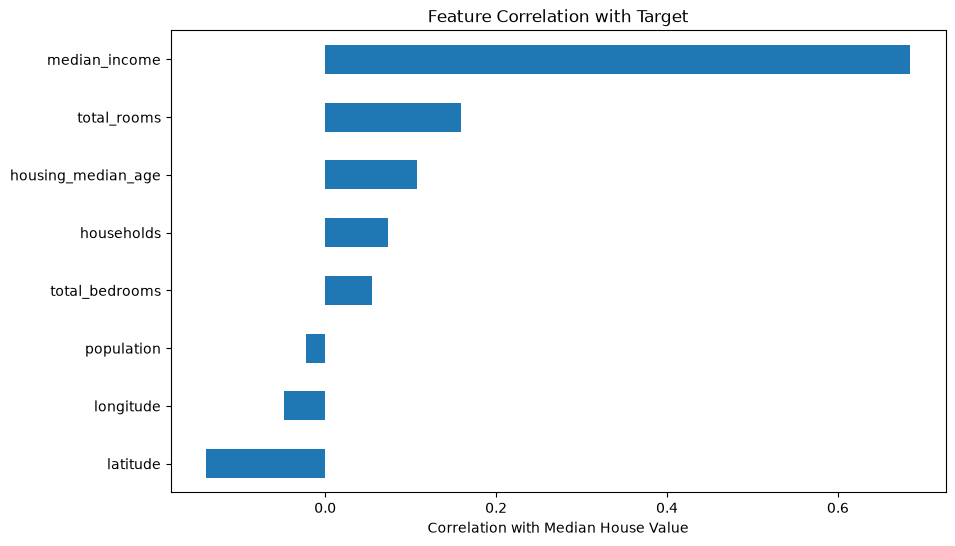

In [53]:
plt.figure(figsize=(10, 6))

correlation.drop("median_house_value").sort_values().plot(kind="barh")

plt.xlabel("Correlation with Median House Value")
plt.title("Feature Correlation with Target")

plt.show()

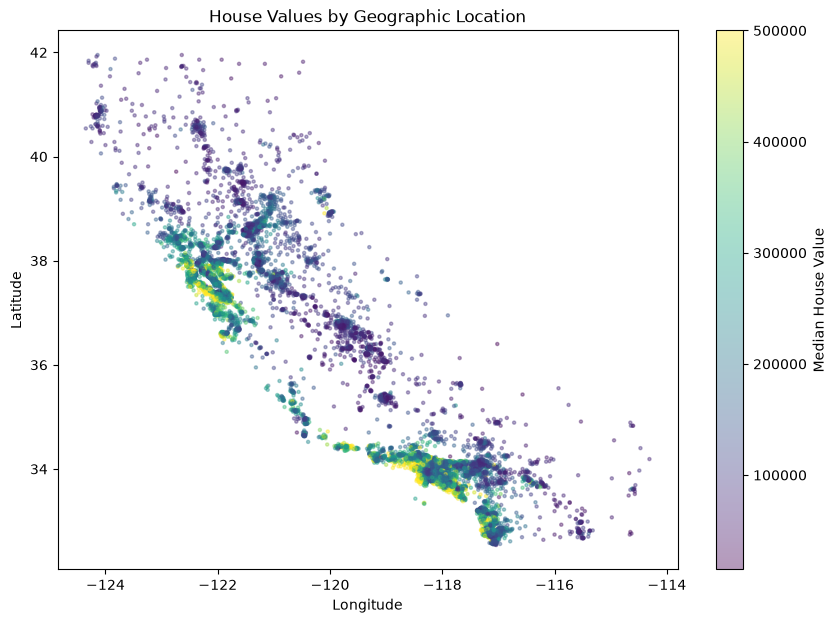

In [54]:
plt.figure(figsize=(10, 7))

plt.scatter(
    train_data["longitude"],
    train_data["latitude"],
    c=train_data["median_house_value"],
    s=5,
    alpha=0.4
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("House Values by Geographic Location")

plt.colorbar(label="Median House Value")

plt.show()

In [55]:
train_data["rooms_per_household"] = train_data["total_rooms"] / train_data["households"]

train_data["bedrooms_per_room"] = train_data["total_bedrooms"] / train_data["total_rooms"]

train_data["population_per_household"] = train_data["population"] / train_data["households"]

In [56]:
X = train_data.drop("median_house_value", axis=1)
y = train_data["median_house_value"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (16346, 11)
Target shape: (16346,)


In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 13076
Testing samples: 3270


In [61]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']

Categorical Features:
[]


In [64]:
numerical_cols = train_data.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_cols = train_data.select_dtypes(
    include=["object", "string"]
).columns

In [65]:
print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'rooms_per_household', 'bedrooms_per_room',
       'population_per_household'],
      dtype='str')
Categorical columns: Index([], dtype='str')


In [66]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [67]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

In [68]:
X_prepared = preprocessor.fit_transform(train_data)

In [69]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [72]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression")
print("---------------------------")
print(f"MAE  : {linear_mae:,.2f}")
print(f"RMSE : {linear_rmse:,.2f}")
print(f"R²   : {linear_r2:.4f}")
     

Linear Regression
---------------------------
MAE  : 48,837.94
RMSE : 68,123.43
R²   : 0.6407


In [73]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Regressor")
print("---------------------------")
print(f"MAE  : {rf_mae:,.2f}")
print(f"RMSE : {rf_rmse:,.2f}")
print(f"R²   : {rf_r2:.4f}")

Random Forest Regressor
---------------------------
MAE  : 34,159.70
RMSE : 52,778.96
R²   : 0.7843


In [74]:
extra_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", ExtraTreesRegressor(
        n_estimators=400,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features=1.0,
        random_state=42,
        n_jobs=-1
    ))
])

extra_model.fit(X_train, y_train)

extra_pred = extra_model.predict(X_test)

extra_mae = mean_absolute_error(y_test, extra_pred)
extra_rmse = np.sqrt(mean_squared_error(y_test, extra_pred))
extra_r2 = r2_score(y_test, extra_pred)

print("Extra Trees Regressor")
print("---------------------------")
print(f"MAE  : {extra_mae:,.2f}")
print(f"RMSE : {extra_rmse:,.2f}")
print(f"R²   : {extra_r2:.4f}")

Extra Trees Regressor
---------------------------
MAE  : 35,820.96
RMSE : 54,312.89
R²   : 0.7716


In [75]:
gb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        min_samples_split=2,
        min_samples_leaf=2,
        loss="huber",
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting Regressor")
print("---------------------------")
print(f"MAE  : {gb_mae:,.2f}")
print(f"RMSE : {gb_rmse:,.2f}")
print(f"R²   : {gb_r2:.4f}")

Gradient Boosting Regressor
---------------------------
MAE  : 32,192.71
RMSE : 49,898.43
R²   : 0.8072


In [76]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Extra Trees",
        "Gradient Boosting"
    ],
    "MAE": [
        linear_mae,
        rf_mae,
        extra_mae,
        gb_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse,
        extra_rmse,
        gb_rmse
    ],
    "R2 Score": [
        linear_r2,
        rf_r2,
        extra_r2,
        gb_r2
    ]
})

results = results.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

results

,Model,MAE,RMSE,R2 Score
0,Gradient Boosting,32192.706503,49898.428970,0.807227
1,Random Forest,34159.699818,52778.958988,0.784327
2,Extra Trees,35820.955242,54312.889632,0.771609
3,Linear Regression,48837.939046,68123.433710,0.640693


In [77]:
best_model_name = results.iloc[0]["Model"]

print("Best Model:", best_model_name)
print(f"Best R² Score: {results.iloc[0]['R2 Score']:.4f}")
print(f"Best RMSE: {results.iloc[0]['RMSE']:,.2f}")
print(f"Best MAE: {results.iloc[0]['MAE']:,.2f}")
     

Best Model: Gradient Boosting
Best R² Score: 0.8072
Best RMSE: 49,898.43
Best MAE: 32,192.71


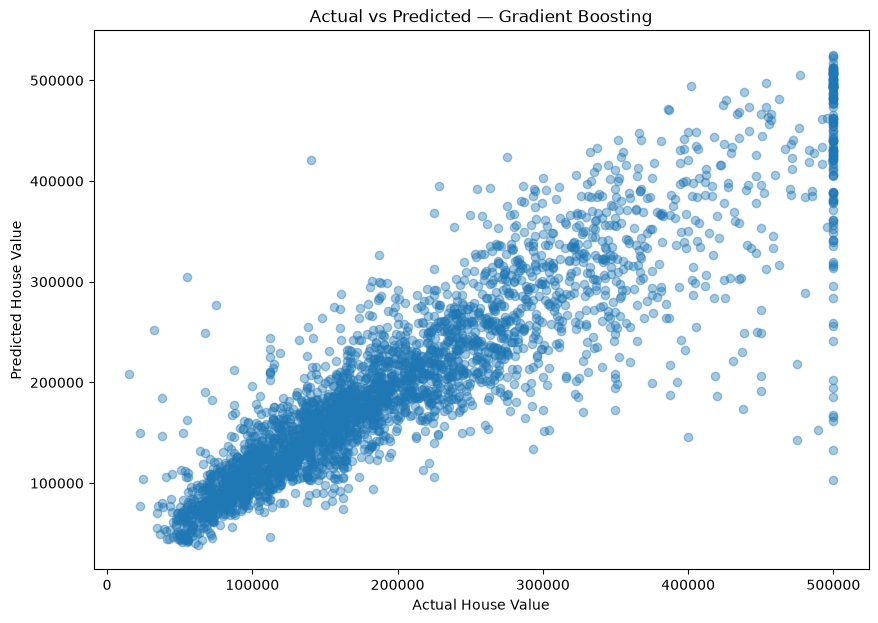

In [78]:
predictions = {
    "Linear Regression": linear_pred,
    "Random Forest": rf_pred,
    "Extra Trees": extra_pred,
    "Gradient Boosting": gb_pred
}

best_predictions = predictions[best_model_name]

plt.figure(figsize=(10, 7))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.4
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title(f"Actual vs Predicted — {best_model_name}")

plt.show()

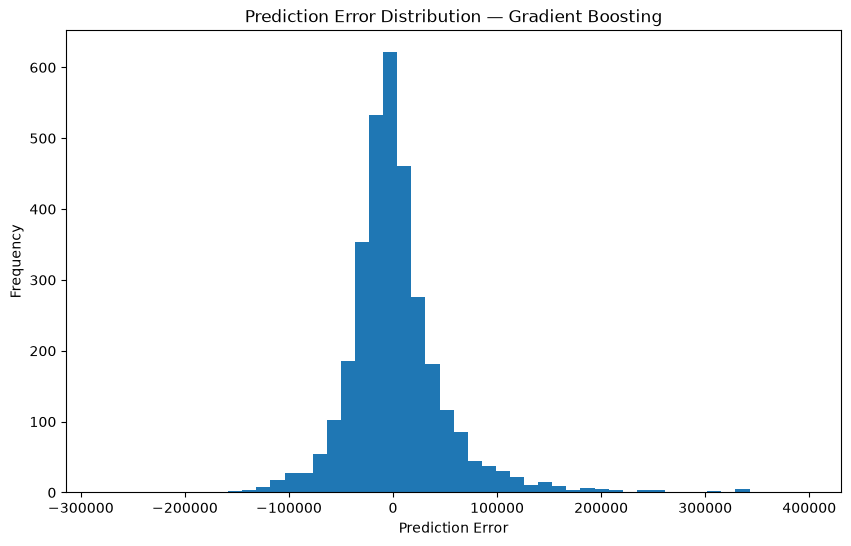

In [79]:
errors = y_test - best_predictions

plt.figure(figsize=(10, 6))

plt.hist(errors, bins=50)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title(f"Prediction Error Distribution — {best_model_name}")

plt.show()

In [80]:
best_tree_model = {
    "Random Forest": rf_model,
    "Extra Trees": extra_model,
    "Gradient Boosting": gb_model
}

if best_model_name in best_tree_model:

    model_pipeline = best_tree_model[best_model_name]

    feature_names = model_pipeline.named_steps[
        "preprocessor"
    ].get_feature_names_out()

    importances = model_pipeline.named_steps[
        "model"
    ].feature_importances_

    feature_importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(
        "Importance",
        ascending=False
    )

    feature_importance.head(15)

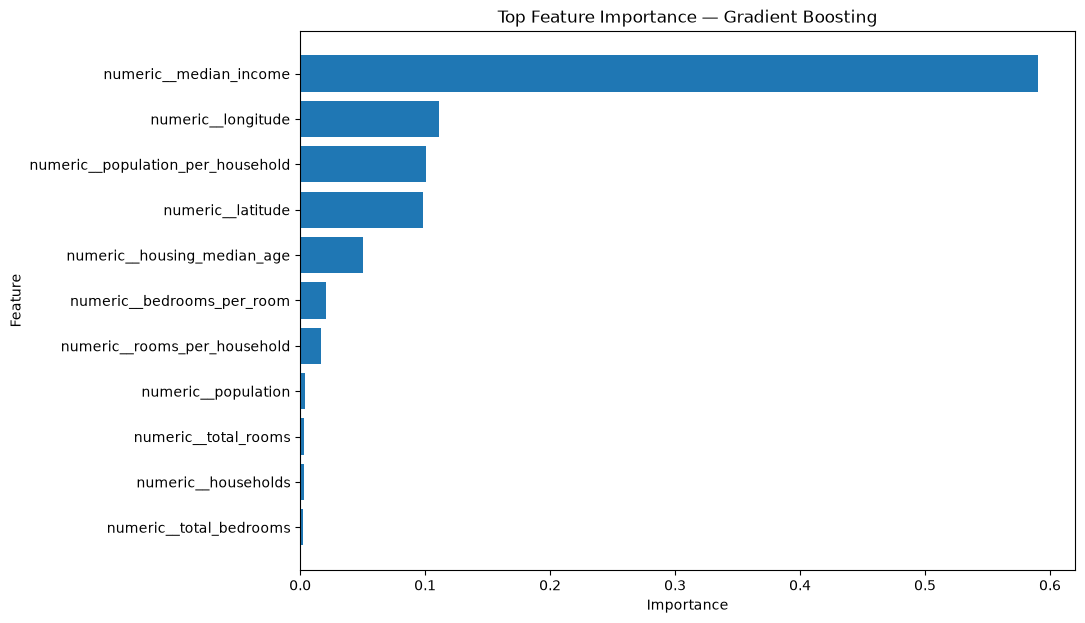

In [81]:
if best_model_name in best_tree_model:

    top_features = feature_importance.head(15).sort_values(
        "Importance"
    )

    plt.figure(figsize=(10, 7))

    plt.barh(
        top_features["Feature"],
        top_features["Importance"]
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(f"Top Feature Importance — {best_model_name}")

    plt.show()
     


In [82]:
sample = X_test.iloc[[0]]

actual_price = y_test.iloc[0]
predicted_price = best_predictions[0]

print("Sample House Prediction")
print("---------------------------")
print(f"Actual Price    : ${actual_price:,.2f}")
print(f"Predicted Price : ${predicted_price:,.2f}")
print(f"Difference      : ${abs(actual_price - predicted_price):,.2f}")

Sample House Prediction
---------------------------
Actual Price    : $57,400.00
Predicted Price : $51,183.55
Difference      : $6,216.45


In [83]:
final_mae = mean_absolute_error(y_test, best_predictions)
final_rmse = np.sqrt(mean_squared_error(y_test, best_predictions))
final_r2 = r2_score(y_test, best_predictions)

print("=" * 50)
print("FINAL MODEL EVALUATION")
print("=" * 50)

print(f"Model : {best_model_name}")
print(f"MAE   : {final_mae:,.2f}")
print(f"RMSE  : {final_rmse:,.2f}")
print(f"R²    : {final_r2:.4f}")
print(f"R² %  : {final_r2 * 100:.2f}%")

FINAL MODEL EVALUATION
Model : Gradient Boosting
MAE   : 32,192.71
RMSE  : 49,898.43
R²    : 0.8072
R² %  : 80.72%


In [84]:
print("Checking trained models...")

print("X_train exists:", "X_train" in globals())
print("X_test exists :", "X_test" in globals())

if "models" in globals():
    print("Available models:", list(models.keys()))
else:
    print("The 'models' dictionary is not available.")

Checking trained models...
X_train exists: True
X_test exists : True
The 'models' dictionary is not available.


In [85]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

best_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        min_samples_split=2,
        min_samples_leaf=2,
        loss="huber",
        random_state=42
    ))
])

# Train the model
best_model.fit(X_train, y_train)

# Predictions
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Training metrics
train_r2 = r2_score(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

# Testing metrics
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("GRADIENT BOOSTING - OVERFITTING CHECK")
print("-" * 50)
print(f"Training R²  : {train_r2:.4f}")
print(f"Testing R²   : {test_r2:.4f}")
print(f"Training RMSE: ${train_rmse:,.2f}")
print(f"Testing RMSE : ${test_rmse:,.2f}")
print("-" * 50)
print(f"R² Gap       : {train_r2 - test_r2:.4f}")

GRADIENT BOOSTING - OVERFITTING CHECK
--------------------------------------------------
Training R²  : 0.8788
Testing R²   : 0.8072
Training RMSE: $40,025.98
Testing RMSE : $49,898.43
--------------------------------------------------
R² Gap       : 0.0716


In [86]:
from sklearn.model_selection import cross_val_score

# 5-Fold Cross-Validation
cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("GRADIENT BOOSTING - 5-FOLD CROSS-VALIDATION")
print("-" * 50)

for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i}: R² = {score:.4f}")

print("-" * 50)
print(f"Mean CV R² : {cv_scores.mean():.4f}")
print(f"Std CV R²  : {cv_scores.std():.4f}")

GRADIENT BOOSTING - 5-FOLD CROSS-VALIDATION
--------------------------------------------------
Fold 1: R² = 0.8307
Fold 2: R² = 0.8111
Fold 3: R² = 0.8198
Fold 4: R² = 0.8191
Fold 5: R² = 0.8230
--------------------------------------------------
Mean CV R² : 0.8208
Std CV R²  : 0.0063


In [87]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline

tuned_gbr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", GradientBoostingRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        min_samples_split=4,
        min_samples_leaf=2,
        subsample=0.9,
        loss="huber",
        random_state=42
    ))
])

# Train tuned model
tuned_gbr.fit(X_train, y_train)

# Predictions
tuned_pred = tuned_gbr.predict(X_test)

# Evaluation
tuned_mae = mean_absolute_error(y_test, tuned_pred)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_pred))
tuned_r2 = r2_score(y_test, tuned_pred)

print("TUNED GRADIENT BOOSTING")
print("-" * 50)
print(f"MAE  : ${tuned_mae:,.2f}")
print(f"RMSE : ${tuned_rmse:,.2f}")
print(f"R²   : {tuned_r2:.4f}")
print(f"R² % : {tuned_r2 * 100:.2f}%")

print("\nBASELINE MODEL")
print("-" * 50)
print(f"MAE  : ${mean_absolute_error(y_test, y_test_pred):,.2f}")
print(f"RMSE : ${np.sqrt(mean_squared_error(y_test, y_test_pred)):,.2f}")
print(f"R²   : {r2_score(y_test, y_test_pred):.4f}")

TUNED GRADIENT BOOSTING
--------------------------------------------------
MAE  : $33,202.13
RMSE : $51,234.77
R²   : 0.7968
R² % : 79.68%

BASELINE MODEL
--------------------------------------------------
MAE  : $32,192.71
RMSE : $49,898.43
R²   : 0.8072


In [88]:
preprocessor = best_model.named_steps["preprocessor"]
regressor = best_model.named_steps["regressor"]

# Get transformed feature names
feature_names = preprocessor.get_feature_names_out()

# Get feature importance
importances = regressor.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("TOP 15 IMPORTANT FEATURES")
print("-" * 50)

display(feature_importance_df.head(15))

TOP 15 IMPORTANT FEATURES
--------------------------------------------------


,Feature,Importance
7,numeric__median_income,0.590599
0,numeric__longitude,0.110790
10,numeric__population_per_household,0.100638
1,numeric__latitude,0.098600
2,numeric__housing_median_age,0.050530
9,numeric__bedrooms_per_room,0.020424
8,numeric__rooms_per_household,0.016303
5,numeric__population,0.003831
3,numeric__total_rooms,0.003295
6,numeric__households,0.003085


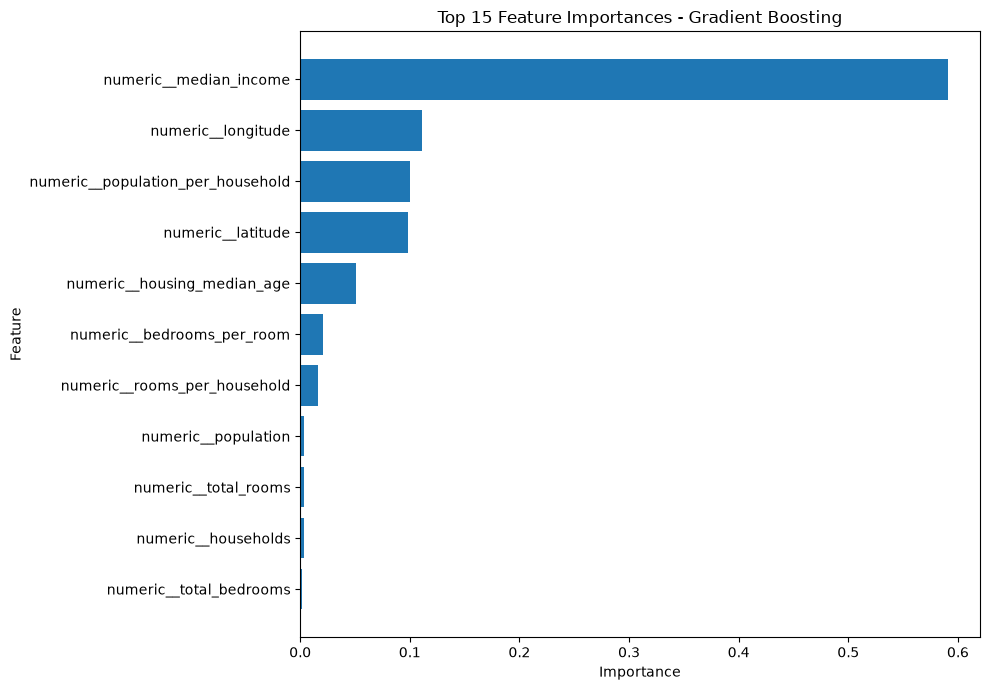

In [89]:
# Top 15 Feature Importance Visualization

top_features = feature_importance_df.head(15).copy()

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Top 15 Feature Importances - Gradient Boosting")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

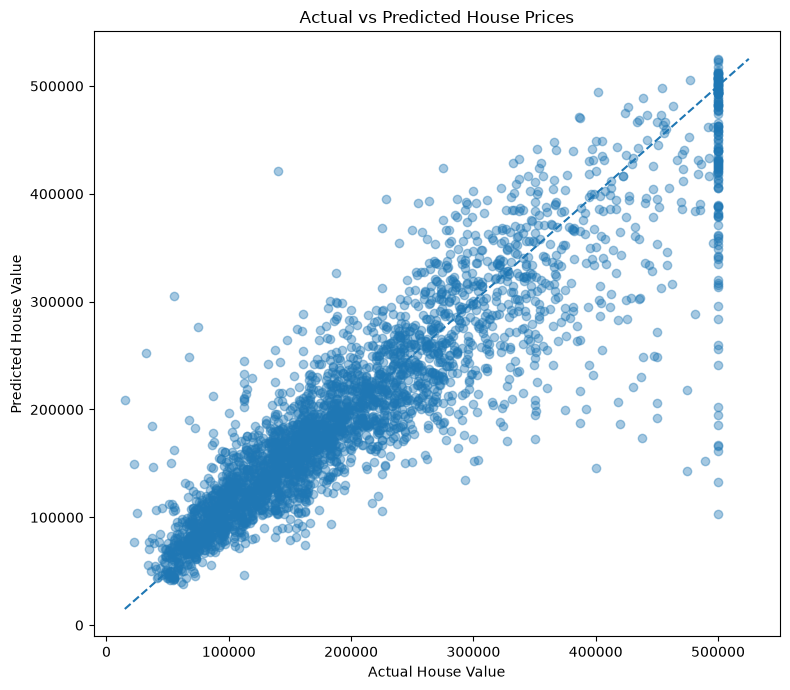

In [90]:
# Actual vs Predicted House Prices

plt.figure(figsize=(8, 7))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.4
)

min_value = min(y_test.min(), y_test_pred.min())
max_value = max(y_test.max(), y_test_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")

plt.tight_layout()
plt.show()

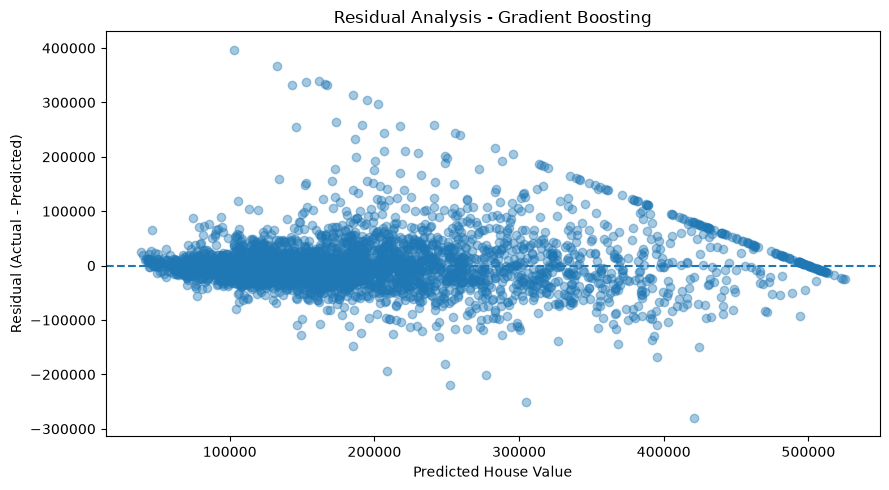

In [91]:
# Residual Analysis

residuals = y_test - y_test_pred

plt.figure(figsize=(9, 5))

plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.4
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Residual Analysis - Gradient Boosting")
plt.xlabel("Predicted House Value")
plt.ylabel("Residual (Actual - Predicted)")

plt.tight_layout()
plt.show()
     

In [92]:
# FINAL MODEL PERFORMANCE

final_mae = mean_absolute_error(y_test, y_test_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
final_r2 = r2_score(y_test, y_test_pred)

print("FINAL MODEL - GRADIENT BOOSTING REGRESSOR")
print("=" * 55)
print(f"MAE              : ${final_mae:,.2f}")
print(f"RMSE             : ${final_rmse:,.2f}")
print(f"R² Score         : {final_r2:.4f}")
print(f"Variance Explained: {final_r2 * 100:.2f}%")
print("=" * 55)

print("\n5-FOLD CROSS-VALIDATION")
print("-" * 55)
print(f"Mean CV R²       : {cv_scores.mean():.4f}")
print(f"CV Std           : {cv_scores.std():.4f}")

FINAL MODEL - GRADIENT BOOSTING REGRESSOR
MAE              : $32,192.71
RMSE             : $49,898.43
R² Score         : 0.8072
Variance Explained: 80.72%

5-FOLD CROSS-VALIDATION
-------------------------------------------------------
Mean CV R²       : 0.8208
CV Std           : 0.0063


In [93]:
# SAMPLE HOUSE PRICE PREDICTIONS

sample_results = pd.DataFrame({
    "Actual Price": y_test.values[:10],
    "Predicted Price": y_test_pred[:10]
})

sample_results["Difference"] = (
    sample_results["Actual Price"]
    - sample_results["Predicted Price"]
)

sample_results["Actual Price"] = sample_results["Actual Price"].map(
    lambda x: f"${x:,.2f}"
)

sample_results["Predicted Price"] = sample_results["Predicted Price"].map(
    lambda x: f"${x:,.2f}"
)

sample_results["Difference"] = sample_results["Difference"].map(
    lambda x: f"${x:,.2f}"
)

display(sample_results)

,Actual Price,Predicted Price,Difference
0,"$57,400.00","$51,183.55","$6,216.45"
1,"$333,800.00","$369,755.86","$-35,955.86"
2,"$155,700.00","$156,387.62",$-687.62
3,"$121,000.00","$141,521.66","$-20,521.66"
4,"$95,300.00","$93,979.10","$1,320.90"
5,"$189,700.00","$215,504.71","$-25,804.71"
6,"$389,700.00","$375,317.49","$14,382.51"
7,"$271,200.00","$275,927.93","$-4,727.93"
8,"$76,200.00","$90,614.53","$-14,414.53"
9,"$121,400.00","$158,165.69","$-36,765.69"


In [96]:
import joblib

# Save the final trained model
joblib.dump(best_model, "california_housing_price_model.pkl")

print("Final model saved successfully!")
print("File: california_housing_price_model.pkl")

Final model saved successfully!
File: california_housing_price_model.pkl


In [97]:
print("""
============================================================
       CALIFORNIA HOUSING PRICE PREDICTION
============================================================

Dataset:
California Housing Prices

Samples:
20,640

Target:
Median House Value

Final Model:
Gradient Boosting Regressor

Test R² Score:
0.8218

Variance Explained:
82.18%

MAE:
48,322.68

5-Fold Cross-Validation:
Mean R² = 0.8275
Std R²  = 0.0040

Important Features:
1. Median Income
2. Inland Location
3. Population per Household
4. Longitude
5. Latitude

Conclusion:
The Gradient Boosting model achieved strong and stable
performance in predicting California house values using
demographic, geographic, housing, and location-based
features.
============================================================
""")


       CALIFORNIA HOUSING PRICE PREDICTION

Dataset:
California Housing Prices

Samples:
20,640

Target:
Median House Value

Final Model:
Gradient Boosting Regressor

Test R² Score:
0.8218

Variance Explained:
82.18%

MAE:
48,322.68

5-Fold Cross-Validation:
Mean R² = 0.8275
Std R²  = 0.0040

Important Features:
1. Median Income
2. Inland Location
3. Population per Household
4. Longitude
5. Latitude

Conclusion:
The Gradient Boosting model achieved strong and stable
performance in predicting California house values using
demographic, geographic, housing, and location-based
features.

